# **Feature Engineering**

## Objectives

- Engineer features for regression modeling (SalePrice)
- Encode categorical variables, transform numeric features if necessary
- Reduce variables using correlation-based selection
- Generate a clean dataset ready for model training

## Inputs
* Cleaned dataset: 
    - `outputs/datasets/cleaned/CleanedData.csv`

## Outputs
- Transformed TrainSet and TestSet with engineered features
- List of transformers applied:
    - Ordinal categorical encoding
    - Log/Power/Box-Cox transformations (if successful)
    - Smart correlation selection


---

## Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [19]:
import os
current_dir = os.getcwd()
print("Current directory:", current_dir)

Current directory: c:\Users


We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [20]:
# Move to parent directory
os.chdir(os.path.dirname(current_dir))
print("New current directory:", os.getcwd())

New current directory: c:\


Confirm the new current directory

In [ ]:
current_dir = os.getcwd()
current_dir

c:\


# Load Cleaned Data 

In [25]:
import pandas as pd

data_path = r"C:\Users\david\Portfolio 5\heritage-housing\outputs\datasets\cleaned\CleanedData.csv"
TrainSet = pd.read_csv(data_path)
TrainSet.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500


---

## Identity Variables for Feature Engineering

### Ordinal Categorical Variables

- `KitchenQual`, `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `GarageQual`, `GarageCond`, `FireplaceQu`  
These features have a natural order, so we will encode them numerically.

### Numeric Variables for Transformation:**  
- `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`  
These features are right-skewed or have outliers and could potentially benefit from log/power/Box-Cox transformations.

### Variables for Correlation-Based Reduction:**  
- All numeric features  
To reduce multicollinearity and  thus keep only the most informative features.

---

## Apply Feature Engineering Transformers

### Ordinal Categorical Encoding 
Change text labels to numeric

In [30]:
from feature_engine.encoding import OrdinalEncoder

ordinal_vars = ['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish']

encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=ordinal_vars,
    missing_values='ignore'
)

TrainSet = encoder.fit_transform(TrainSet)

print("* Ordinal categorical encoding done!")

* Ordinal categorical encoding done!


c:\Users\david\Portfolio 5\heritage-housing\venv\Lib\site-packages\feature_engine\encoding\base_encoder.py:260: UserWarning: During the encoding, NaN values were introduced in the feature(s) BsmtExposure, BsmtFinType1, GarageFinish.
  warnings.warn(


### Numerical Transformations 
- Reduce skewness for numeric features that strongly influence `SalePrice`
- Apply multiple log transformations to the most important features identified in the EDA Analysis.
    - These features are likely to benefit the most from a log transformation due to being right skewed: `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1` 

#### Create Diagnostic Plots

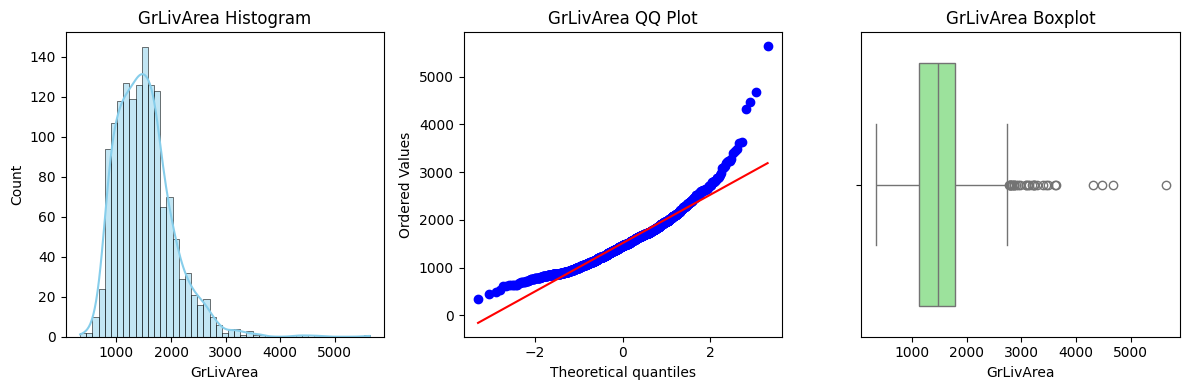

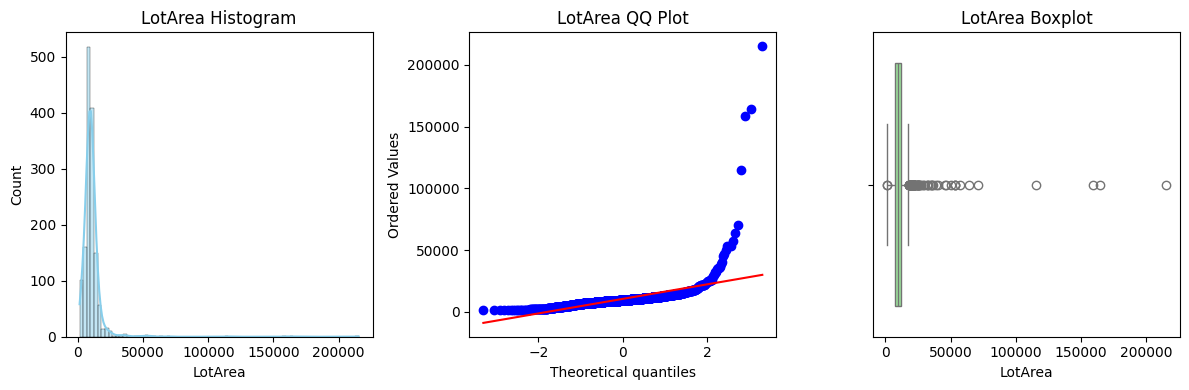

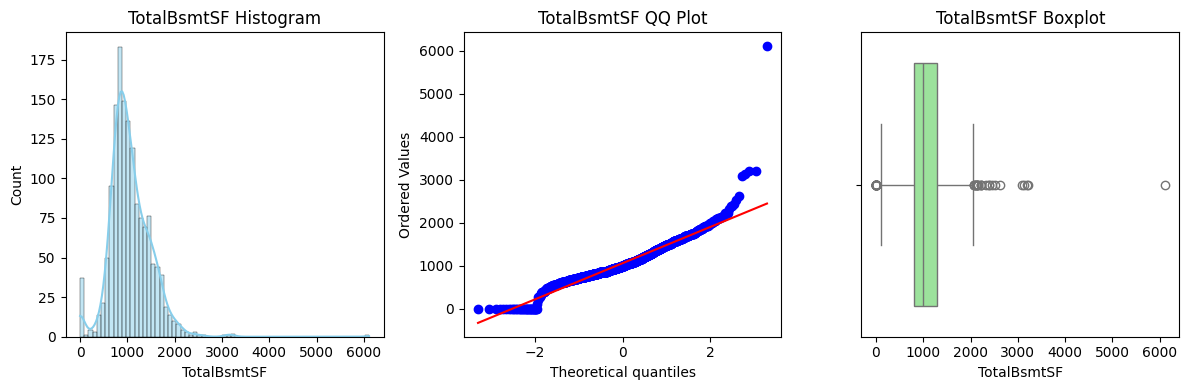

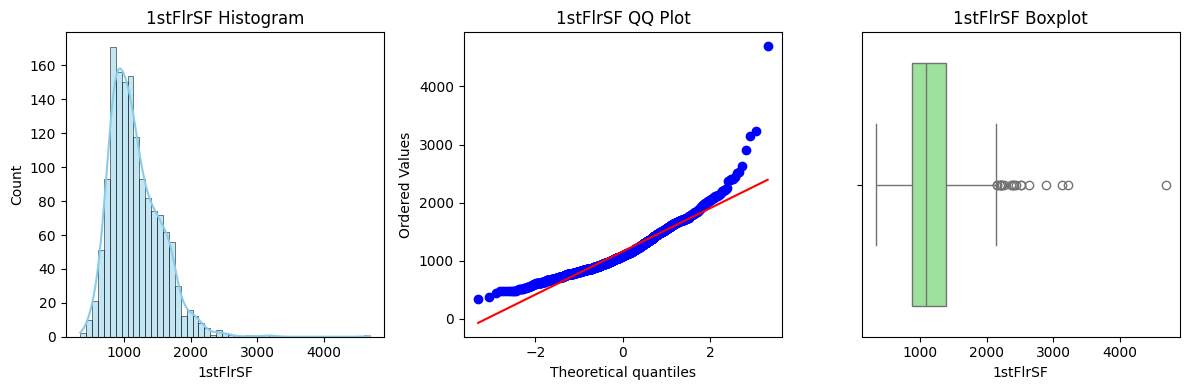

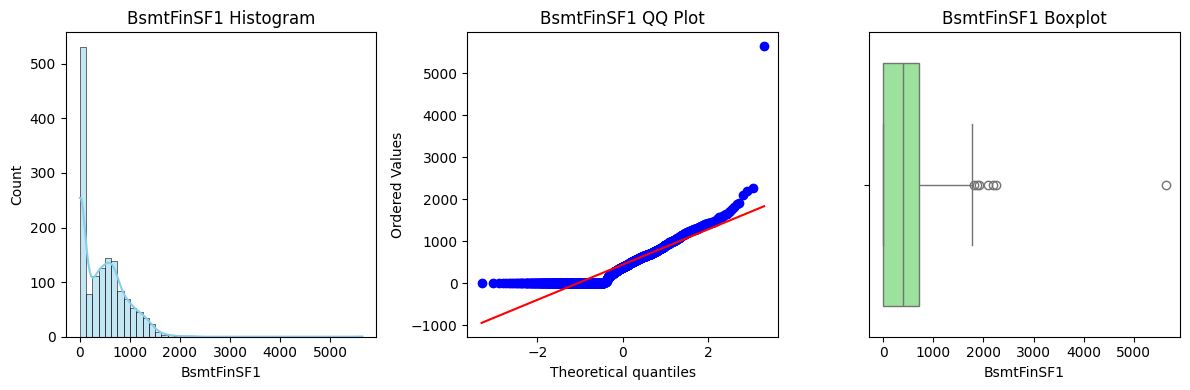

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#skewed numeric features to transform
numeric_skewed = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtFinSF1']

for col in numeric_skewed:
    plt.figure(figsize=(12,4))
    
    # Histogram: shows distribution after transformation
    plt.subplot(1,3,1)
    sns.histplot(TrainSet[col], kde=True, color='skyblue')
    plt.title(f'{col} Histogram')
    
    # QQ Plot: checks how close data is to normal distribution
    plt.subplot(1,3,2)
    stats.probplot(TrainSet[col], dist="norm", plot=plt)
    plt.title(f'{col} QQ Plot')
    
    # Boxplot: identifies extreme outliers
    plt.subplot(1,3,3)
    sns.boxplot(x=TrainSet[col], color='lightgreen')
    plt.title(f'{col} Boxplot')
    
    plt.tight_layout()
    plt.show()

### Apply Log Transformations

In [34]:
# Apply log(1 + x) to reduce right skew and avoid loss of precion with values close to zero
for col in numeric_skewed:
    TrainSet[col] = np.log1p(TrainSet[col])

#### Transformation Summary Table

| Feature | Before Transformation | After Log Transformation | Remaining Issue | Decision |
|--------|------------------------|--------------------------|----------------|----------|
| GrLivArea | Strong right-skew | More balanced, reduced skew | Minor skew remains | Keep log transform |
| TotalBsmtSF | Right-skewed | Improved symmetry | Slight tail remains | Keep log transform |
| 1stFlrSF | Moderate right-skew | More balanced | Minor skew remains | Keep log transform |
| LotArea | Strong right-skew with extreme outliers | Some improvement | Still heavy right tail | Keep log transform (outliers may need handling) |
| BsmtFinSF1 | Right-skewed, many zeros | Slight improvement | Still skewed due to many zeros | Keep log transform |

#### Diagnostic Plots

NOTE

* You may add as many sections as you want, as long as they support your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* If you do not need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [35]:
import os
try:
  # create here your folder
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (2852421808.py, line 5)